# import the required dataset ( UCI : bank marketing )

In [194]:
import pandas as pd
import numpy as np

In [195]:
!wget https://raw.githubusercontent.com/durveshcollegeid/sem5_ML/refs/heads/main/sep11/bank/bank-full.csv

--2026-09-11 06:32:37--  https://raw.githubusercontent.com/durveshcollegeid/sem5_ML/refs/heads/main/sep11/bank/bank-full.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4610348 (4.4M) [text/plain]
Saving to: ‘bank-full.csv.6’

bank-full.csv.6     100%[===================>]   4.40M  --.-KB/s    in 0.08s   

2026-09-11 06:32:37 (58.4 MB/s) - ‘bank-full.csv.6’ saved [4610348/4610348]



In [196]:
path  = "/content/bank-full.csv"

In [197]:
df = pd.read_csv( path, sep=';' )
df_backup = pd.read_csv( path, sep=';' )

# find missing/null values

In [198]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [199]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [200]:
#no missing values found in the dataset

# split data into features and target

In [201]:
y = df["y"]
X = df.drop( "y", axis=1 )

In [202]:
y = y.map( { "yes":1, "no":0 } )

# Perform encoding on the binary features ( value = yes/no )

In [203]:
X[ "default" ] = X[ "default" ].map( { "yes":1, "no":0 } )

In [204]:
X[ "housing" ] = X[ "housing" ].map( { "yes":1, "no":0 } )

In [205]:
X[ "loan" ] = X[ "loan" ].map( { "yes":1, "no":0 } )

# perform one hot encoding on features with many categories

In [206]:
one_hot_cols = [ "job", "marital", "education", "contact", "month", "poutcome" ]

In [207]:
for col in one_hot_cols:
  one_hot_df = pd.get_dummies( X[ col ], prefix=col )
  X = X.drop( col, axis=1 )
  X = pd.concat( [ X, one_hot_df ], axis=1 )

# drop the irrelevant features

In [208]:
import matplotlib.pyplot as plt

(array([4.2882e+04, 1.6220e+03, 4.2000e+02, 1.6500e+02, 7.5000e+01,
        3.3000e+01, 7.0000e+00, 3.0000e+00, 2.0000e+00, 2.0000e+00]),
 array([ 1. ,  7.2, 13.4, 19.6, 25.8, 32. , 38.2, 44.4, 50.6, 56.8, 63. ]),
 <BarContainer object of 10 artists>)

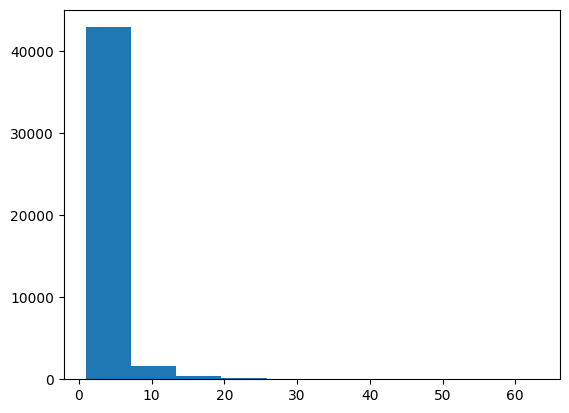

In [209]:
plt.hist( X["campaign"]  )

(array([3.7516e+04, 2.2990e+03, 2.1540e+03, 1.8250e+03, 1.2290e+03,
        9.8000e+01, 3.9000e+01, 1.8000e+01, 1.8000e+01, 1.5000e+01]),
 array([ -1. ,  86.2, 173.4, 260.6, 347.8, 435. , 522.2, 609.4, 696.6,
        783.8, 871. ]),
 <BarContainer object of 10 artists>)

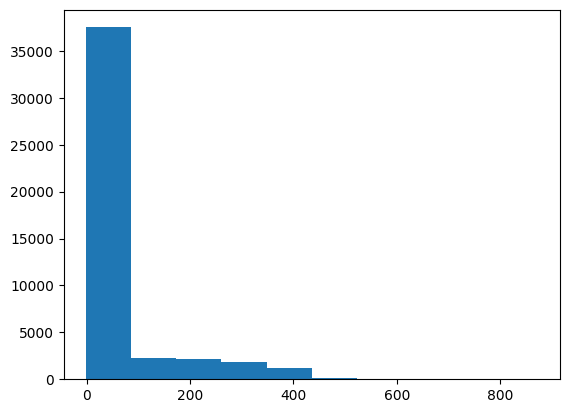

In [210]:
plt.hist( X["pdays"]  )

In [211]:
#plt.hist( X["education"]  )

# transforming boolean values to integers

In [212]:
for col in X.columns:
  if X[ col ].dtype == bool:
    X[ col ] = X[ col ].astype( int )

# split the data into training and testing dataset

In [213]:
from sklearn.model_selection import train_test_split

In [214]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42 )

# find outliers for each feature in the dataset

skipped for now

(array([3.1643e+04, 4.2180e+03, 2.3300e+02, 4.3000e+01, 1.8000e+01,
        4.0000e+00, 5.0000e+00, 1.0000e+00, 2.0000e+00, 1.0000e+00]),
 array([ -8019. ,   2995.6,  14010.2,  25024.8,  36039.4,  47054. ,
         58068.6,  69083.2,  80097.8,  91112.4, 102127. ]),
 <BarContainer object of 10 artists>)

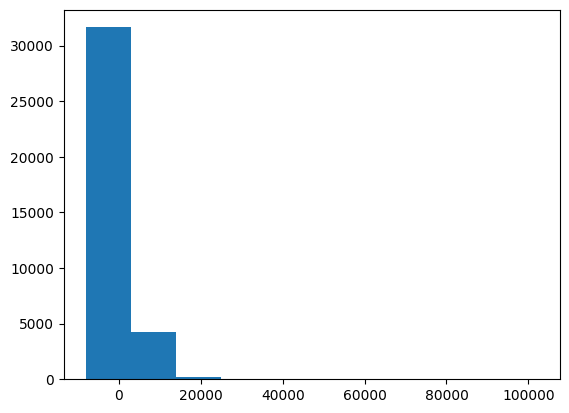

In [215]:
plt.hist( X_train["balance"]  )

In [216]:
#q1 = X_train["balance"].quantile( 0.25 )
#q2 = X_train["balance"].quantile( 0.50 )
#q3 = X_train["balance"].quantile( 0.75 )
#iqr = q3 - q1


In [217]:
#LL = q1 - 1.5*iqr
#UL = q3 + 1.5*iqr

In [218]:
#X_train_new = X_train[ ( X_train["balance"] > LL ) & ( X_train["balance"] < UL ) ]
#y_train_new = y_train[ ( X_train["balance"] > LL ) & ( X_train["balance"] < UL ) ]

In [219]:
#len( X_train_new ), len( y_train_new )

In [220]:
#since the data for majority of the features is either categorical (and then transformed into booleans), features other than "balance" does not contain outlier values

In [221]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36168 entries, 3344 to 15795
Data columns (total 48 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   age                  36168 non-null  int64
 1   default              36168 non-null  int64
 2   balance              36168 non-null  int64
 3   housing              36168 non-null  int64
 4   loan                 36168 non-null  int64
 5   day                  36168 non-null  int64
 6   duration             36168 non-null  int64
 7   campaign             36168 non-null  int64
 8   pdays                36168 non-null  int64
 9   previous             36168 non-null  int64
 10  job_admin.           36168 non-null  int64
 11  job_blue-collar      36168 non-null  int64
 12  job_entrepreneur     36168 non-null  int64
 13  job_housemaid        36168 non-null  int64
 14  job_management       36168 non-null  int64
 15  job_retired          36168 non-null  int64
 16  job_self-employed    361

# Training a decision tree model

In [222]:
from sklearn.tree import DecisionTreeClassifier

In [223]:
model_dct = DecisionTreeClassifier()

In [224]:
model_dct.fit( X_train, y_train )

DecisionTreeClassifier()

# predicting on test data using decision tree model

In [225]:
y_pred_dct = model_dct.predict( X_test )

# Training a knn model

In [226]:
from sklearn.neighbors import KNeighborsClassifier

In [227]:
model_knn = KNeighborsClassifier(  )

In [228]:
model_knn.fit( X_train, y_train )

KNeighborsClassifier()

# predicting on test data using knn model

In [229]:
y_pred_knn = model_knn.predict( X_test )

# evaluating accuracy scores for the models

In [230]:
from sklearn.metrics import accuracy_score

In [231]:
acc_dct = accuracy_score( y_test, y_pred_dct )


In [232]:
print( acc_dct )

0.8743779719119761


In [233]:
acc_knn = accuracy_score( y_test, y_pred_knn )

In [234]:
print( acc_knn )

0.8754837996240186


# obtaining pie charts to visualize performance of the models

Text(0.5, 1.0, 'Decision Tree performance')

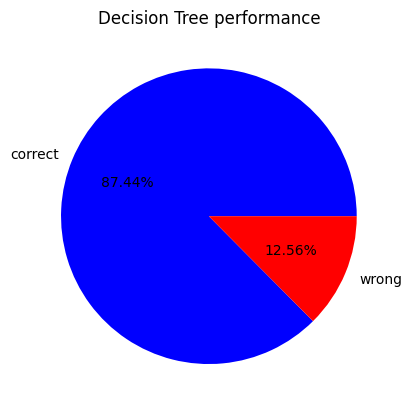

In [235]:
plt.pie( x = [ 100*(acc_dct), 100*(1-acc_dct) ], colors = ["blue", "red"], labels = [ "correct", "wrong" ], autopct='%.2f%%'  )
plt.title(  "Decision Tree performance" )

Text(0.5, 1.0, 'KNN performance')

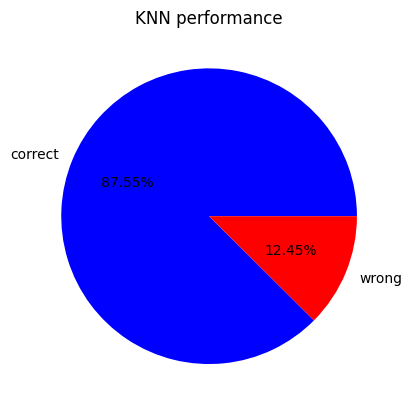

In [236]:
plt.pie( x = [ 100*(acc_knn), 100*(1-acc_knn) ], colors = ["blue", "red"], labels = [ "correct", "wrong" ],  autopct='%.2f%%' )
plt.title( "KNN performance" )